# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [1]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [11]:
# Load the data from the available CSV file
df = pd.read_csv('/content/dataset_heart.csv')

# Fix column names with trailing spaces
df.columns = df.columns.str.strip()

# Understand the data
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
display(df.head())

# Define the target column - identified from df.info()
target_col = 'heart disease'

# Remove target column from the training data
X = df.drop(columns=[target_col])
y = df[target_col]

# Split the data into train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1



Training set size: (216, 13)
Testing set size: (54, 13)


### Basic visual checks

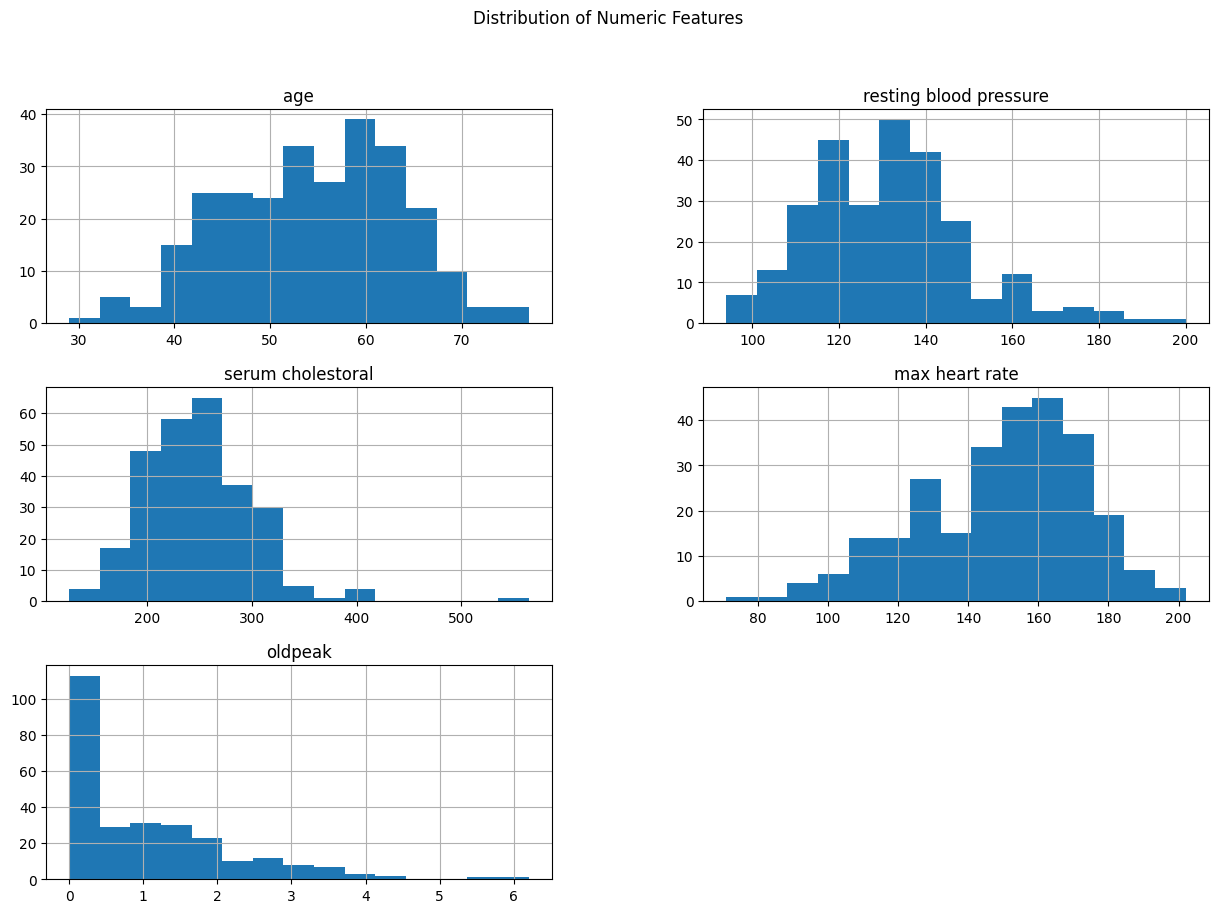

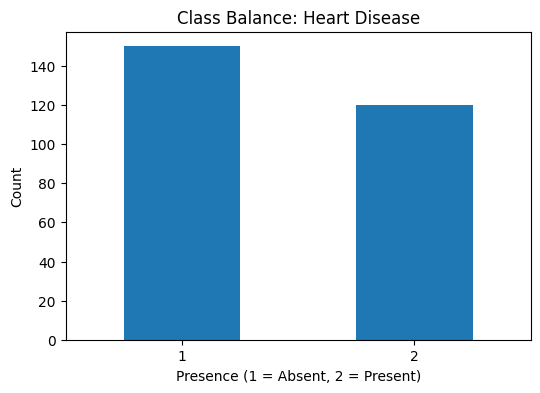

In [7]:
# Pick a few numeric columns and plot histograms
numeric_cols = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']
df[numeric_cols].hist(bins=15, figsize=(15, 10))
plt.suptitle('Distribution of Numeric Features')
plt.show()

# Plot class balance as a bar chart
plt.figure(figsize=(6, 4))
df['heart disease'].value_counts().plot(kind='bar')
plt.title('Class Balance: Heart Disease')
plt.xlabel('Presence (1 = Absent, 2 = Present)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Preprocessing pipeline

In [8]:
# Identify categorical and numerical columns
# Binary columns like 'sex' can be treated as numeric or categorical;
# Here we will treat columns with few unique values as categorical.
cat_cols = ['sex', 'chest pain type', 'fasting blood sugar', 'resting electrocardiographic results', 'exercise induced angina', 'ST segment', 'thal']
num_cols = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak', 'major vessels']

# Build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

## Helper - evaluation function

In [9]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available."""
    y_pred = model.predict(X_test)

    # Note: Target values are 1 and 2. For binary metrics, we use pos_label=2
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=2),
        'recall': recall_score(y_test, y_pred, pos_label=2),
        'f1': f1_score(y_test, y_pred, pos_label=2),
    }

    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"{k.capitalize()}: {v:.4f}")

    # Confusion Matrix
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    cm = confusion_matrix(y_test, y_pred)
    im = ax[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax[0].set_title(f'Confusion Matrix: {name}')
    fig.colorbar(im, ax=ax[0])
    ax[0].set_xlabel('Predicted Label')
    ax[0].set_ylabel('True Label')

    # ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        # Adjust labels for roc_auc_score which expects [0, 1] or specific classes
        fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=2)
        auc_val = roc_auc_score(y_test, y_prob)
        ax[1].plot(fpr, tpr, label=f'AUC = {auc_val:.2f}')
        ax[1].plot([0, 1], [0, 1], 'k--')
        ax[1].set_title(f'ROC Curve: {name}')
        ax[1].set_xlabel('False Positive Rate')
        ax[1].set_ylabel('True Positive Rate')
        ax[1].legend()
    else:
        ax[1].text(0.5, 0.5, 'ROC not available', ha='center', va='center')

    plt.tight_layout()
    plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

--- Logistic Regression (No GS) ---
Accuracy: 0.8704
Precision: 0.8148
Recall: 0.9167
F1: 0.8627


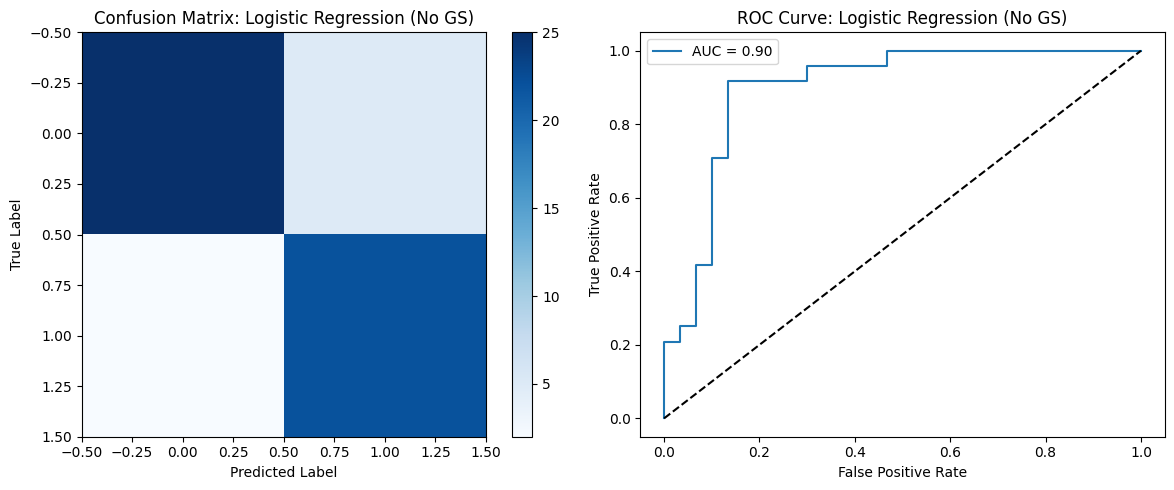

In [12]:
# Create a Pipeline with preprocessor and LogisticRegression
pipe_lr = Pipeline(steps=[
    ('preprocessor', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# Fit on training data
pipe_lr.fit(X_train, y_train)

# Evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('Logistic Regression (No GS)', pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
--- Logistic Regression (Grid Search) ---
Accuracy: 0.8704
Precision: 0.8400
Recall: 0.8750
F1: 0.8571


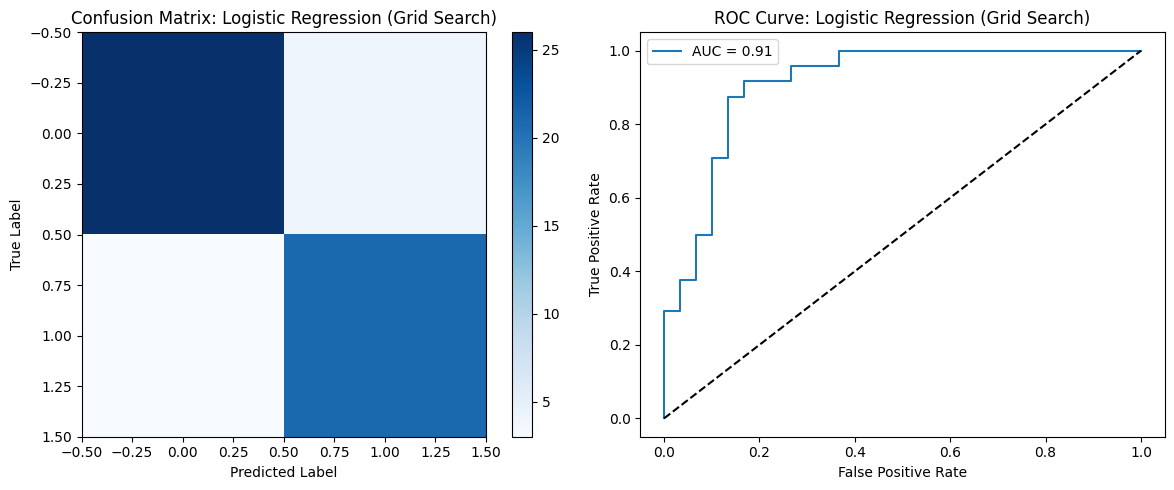

In [13]:
# Build a Pipeline same as above for consistency
pipe_lr_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# Define param_grid for lr__C and lr__penalty
# C is the inverse of regularization strength; smaller values specify stronger regularization.
param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

# GridSearchCV with 5-fold cross-validation, optimizing for F1-score
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print(f'Best params: {grid_lr.best_params_}')
best_lr = grid_lr.best_estimator_

# Evaluate the best estimator found by GridSearch
lr_gs_metrics = eval_and_report('Logistic Regression (Grid Search)', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

--- SVM (No GS) ---
Accuracy: 0.8519
Precision: 0.8077
Recall: 0.8750
F1: 0.8400


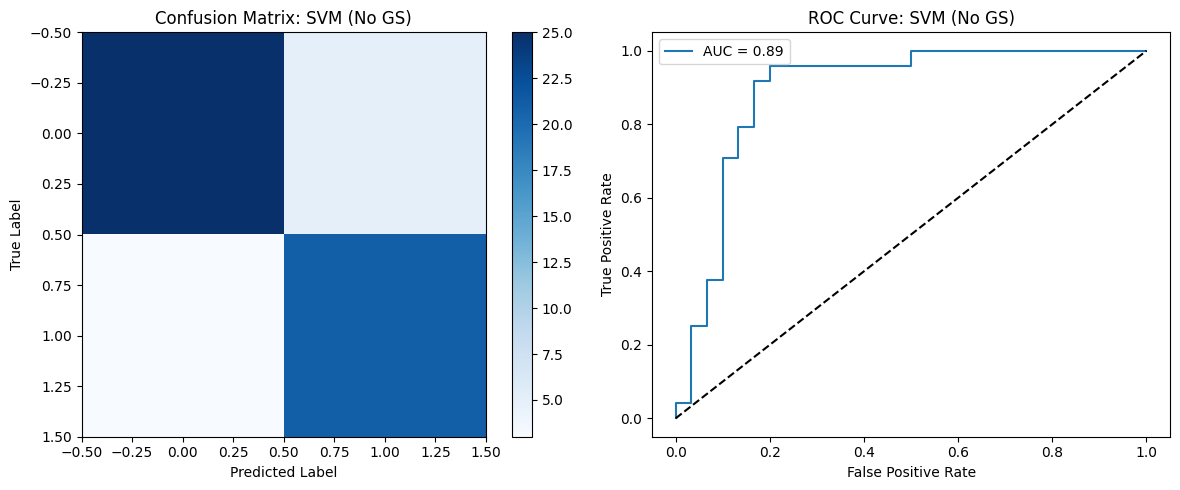

In [14]:
# Build a Pipeline for SVM
# We use probability=True so we can calculate ROC AUC later
pipe_svm = Pipeline(steps=[
    ('preprocessor', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])

# Fit on training data
pipe_svm.fit(X_train, y_train)

# Evaluate with eval_and_report
svm_no_gs_metrics = eval_and_report('SVM (No GS)', pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
--- SVM (Grid Search) ---
Accuracy: 0.8519
Precision: 0.8333
Recall: 0.8333
F1: 0.8333


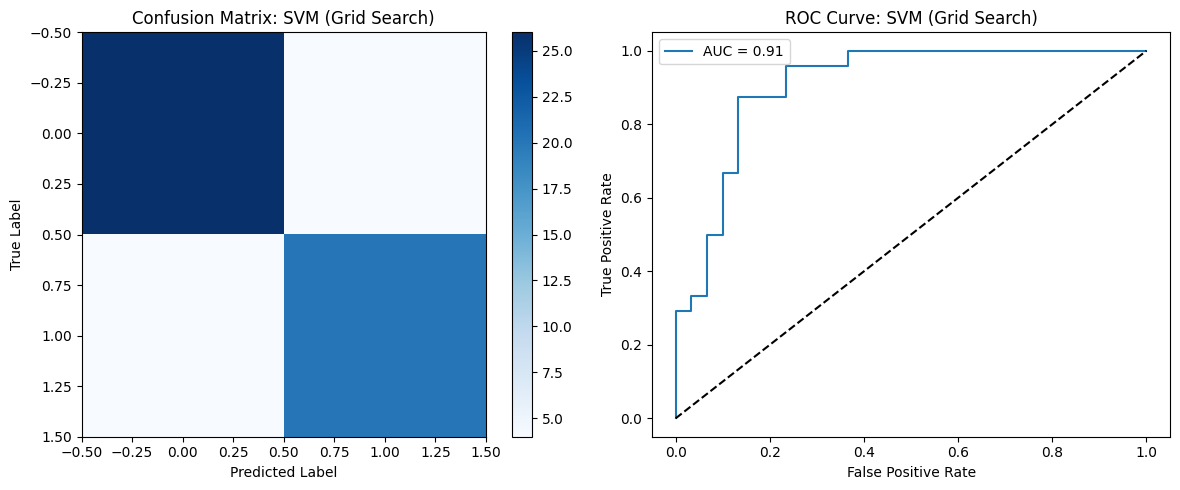

In [15]:
# Pipeline with SVC(probability=True) so we can plot ROC
pipe_svm_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

# Define param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.001]
}

# GridSearchCV with 5-fold cross-validation, optimizing for F1-score
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print(f'Best params: {grid_svm.best_params_}')
best_svm = grid_svm.best_estimator_

# Evaluate the best estimator found by GridSearch
svm_gs_metrics = eval_and_report('SVM (Grid Search)', best_svm, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search

In [17]:
# Build an XGBClassifier and wrap it in a Pipeline with preprocessor
# XGBoost expects 0/1 labels. Our target is currently 1/2, so we map them to 0/1.
y_train_xgb = y_train.map({1: 0, 2: 1})
y_test_xgb = y_test.map({1: 0, 2: 1})

pipe_xgb = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE, eval_metric='logloss'))
])

# Fit the pipeline
pipe_xgb.fit(X_train, y_train_xgb)

# Evaluate using a modified call to eval_and_report since pos_label is now 1
def eval_and_report_xgb(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }
    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"{k.capitalize()}: {v:.4f}")
    return metrics

# Fix: Pass the mapped y_test_xgb instead of y_test
xgb_no_gs_metrics = eval_and_report_xgb('XGBoost (No GS)', pipe_xgb, X_test, y_test_xgb)

--- XGBoost (No GS) ---
Accuracy: 0.8333
Precision: 0.8000
Recall: 0.8333
F1: 0.8163


## Exercise 7 - XGBoost with Grid Search

In [18]:
# Pipeline for XGBoost
pipe_xgb_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgb', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
])

# Define param_grid for XGBoost tuning
xgb_param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__max_depth': [3, 4, 5],
    'xgb__subsample': [0.8, 1.0]
}

# GridSearchCV optimizing for F1
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train, y_train_xgb)

print(f'Best params: {grid_xgb.best_params_}')
best_xgb = grid_xgb.best_estimator_

# Evaluate the best XGBoost model
xgb_gs_metrics = eval_and_report_xgb('XGBoost (Grid Search)', best_xgb, X_test, y_test_xgb)

Best params: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 300, 'xgb__subsample': 1.0}
--- XGBoost (Grid Search) ---
Accuracy: 0.8148
Precision: 0.7692
Recall: 0.8333
F1: 0.8000


## Compare models

In [19]:
# Build a comparison DataFrame from the metrics dictionaries
summary = {
    'Logistic Regression (Baseline)': lr_no_gs_metrics,
    'Logistic Regression (Tuned)': lr_gs_metrics,
    'SVM (Baseline)': svm_no_gs_metrics,
    'SVM (Tuned)': svm_gs_metrics,
    'XGBoost (Baseline)': xgb_no_gs_metrics,
    'XGBoost (Tuned)': xgb_gs_metrics
}

comparison_df = pd.DataFrame.from_dict(summary, orient='index')

# Display the final results, sorted by F1-score
display(comparison_df.sort_values(by='f1', ascending=False))

,accuracy,precision,recall,f1
Logistic Regression (Baseline),0.870370,0.814815,0.916667,0.862745
Logistic Regression (Tuned),0.870370,0.840000,0.875000,0.857143
SVM (Baseline),0.851852,0.807692,0.875000,0.840000
SVM (Tuned),0.851852,0.833333,0.833333,0.833333
XGBoost (Baseline),0.833333,0.800000,0.833333,0.816327
XGBoost (Tuned),0.814815,0.769231,0.833333,0.800000
